In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:

import src_v1.utils as utils 
import matplotlib.pyplot as plt
T = 1000


In [26]:
probes = ['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M',
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M',
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M',
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW08R03M']

weights_paths = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"


from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def loo_svm_tpeak(probe_list, t_peak, k=1, collapsed=True, model_dim='3d', C=1.0, kernel='rbf', volta=False):
    results = {}
    
    for test_probe in probe_list:
        train, test, _, _, _, _ = utils.load_activation_data(
            weights_paths,
            test_probe=test_probe,
            collapsed=collapsed,
            ret_np=True,
            model_dim=model_dim,
            volta=volta
        )
        
        
        # Extract features at t_peak only
        X_tr = train[0][:, t_peak, :]  # (N_train, n_experts)
        X_te = test[0][:, t_peak, :]   # (N_test, n_experts)
        y_tr = train[1]
        y_te = test[1]
        
        n_expert = train[0].shape[2]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr.reshape(-1,k*n_expert))
        X_te = scaler.transform(X_te.reshape(-1,k*n_expert))
        
        clf = SVC(C=C, kernel=kernel, class_weight='balanced')
        clf.fit(X_tr, y_tr)
        
        acc = clf.score(X_te, y_te)
        report = classification_report(y_te, clf.predict(X_te),
                                        target_names=['DA', '5HT', 'NE'],
                                        output_dict=True)
        
        results[test_probe] = {'acc': acc, 'report': report}
        print(f"{test_probe}: acc={acc:.3f}")
    
    # Summary
    accs = [v['acc'] for v in results.values()]
    print(f"\nMean acc: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    
    return results


def plot_loo_results(results, model_dim='3d'):
    probes = list(results.keys())
    short_names = [p.split('__')[1] for p in probes]  # just the probe name
    
    accs = [results[p]['acc'] for p in probes]
    da_f1  = [results[p]['report']['DA']['f1-score'] for p in probes]
    ht_f1  = [results[p]['report']['5HT']['f1-score'] for p in probes]
    ne_f1  = [results[p]['report']['NE']['f1-score'] for p in probes]
    
    x = np.arange(len(probes))
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - 1.5*width, da_f1,  width, label='DA',  color='steelblue')
    ax.bar(x - 0.5*width, ht_f1,  width, label='5HT', color='darkorange')
    ax.bar(x + 0.5*width, ne_f1,  width, label='NE',  color='green')
    ax.bar(x + 1.5*width, accs,   width, label='Overall acc', color='gray', alpha=0.7)
    
    ax.axhline(1/3, color='red', linestyle='--', label='Chance')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.set_ylabel('F1-score / Accuracy')
    ax.set_title(f'Leave-One-Out SVM results — {model_dim} DynaMix')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
def plot_classification_report(y_true, y_pred, t_peak, acc, title="Full sweep", classes=['DA', '5HT', 'NE']):
    
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    metrics = ['precision', 'recall', 'f1-score']
    data = np.array([[report[c][m] for m in metrics] for c in classes])
    
    fig, ax = plt.subplots(figsize=(5, 3))
    im = ax.imshow(data, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(['Precision', 'Recall', 'F1'], fontsize=11)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes, fontsize=12, fontweight='bold')
    
    for i in range(len(classes)):
        for j in range(len(metrics)):
            val = data[i, j]
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=13, color=color, fontweight='bold')
    
    ax.set_title(f'{title} | acc: {acc:.3f} | t_peak: {t_peak}', fontsize=11, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()



# Raw Voltammogram Classification

In [29]:
acc_over_t_full_raw_volta = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_full_raw_volta.npy")
acc_over_t_full_raw_volta_mean = acc_over_t_full_raw_volta.mean(axis=0)

Text(0, 0.5, 'Accuracy')

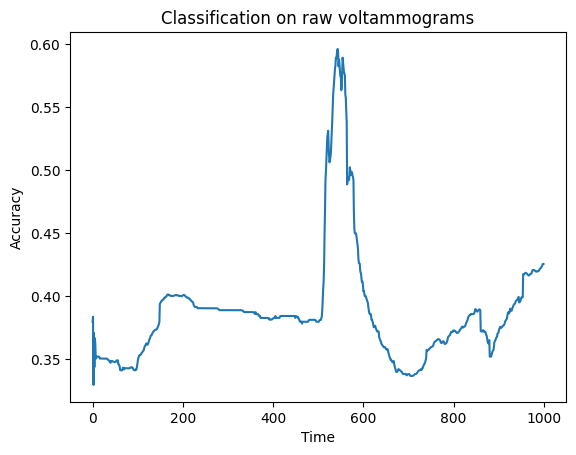

In [30]:

plt.plot(range(T), acc_over_t_full_raw_volta_mean)
plt.title("Classification on raw voltammograms")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [31]:
t_peak_raw = np.argmax(acc_over_t_full_raw_volta_mean)

svm_results_raw = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_raw, volta=True)

Found 28 paths
Getting pairs collapsed.
Getting raw voltammograms
First activation shape(35, 1000, 1)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 1)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_

/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

First activation shape(35, 1000, 1)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 1)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW08R03M']
Test probe:  ALCIS_155_macroREF

/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/team/.pyenv/versions/dynamix/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

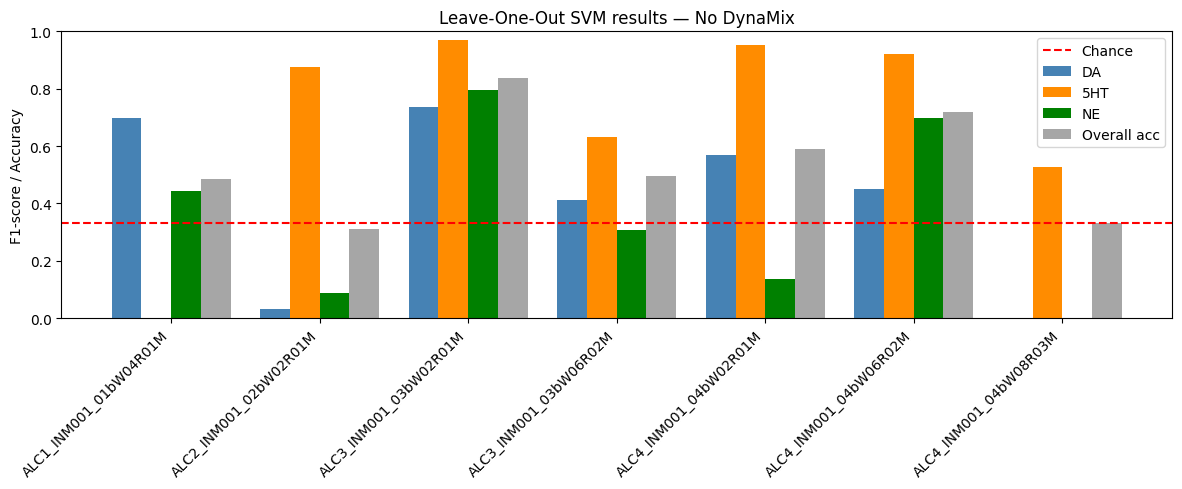

In [32]:
plot_loo_results(svm_results_raw, model_dim='No')

# On ALC3 probe, confusion matrix compared

In [27]:
best_probe = 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
weights_paths = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
train_full, test_full, y_mean_full, y_std_full, _, test_probe_full =  utils.load_activation_data(weights_paths,test_probe=best_probe,collapsed=False,ret_np=True,volta=True)

Found 28 paths
Getting pairs not collapsed.
Getting raw voltammograms
First activation shape(5250, 1000, 1)
First label shape(5250, 4)
Expert activation set shape: (127050, 1000, 1)
Labels shape: (127050, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 13950 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 13950 samples
Total valid samples: 97650
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF_

t_peak: 537, acc: 0.9354838709677419
              precision    recall  f1-score   support

          DA       1.00      0.90      0.95      4650
         5HT       0.91      1.00      0.95      4650
          NE       0.90      0.90      0.90      4650

    accuracy                           0.94     13950
   macro avg       0.94      0.94      0.94     13950
weighted avg       0.94      0.94      0.94     13950



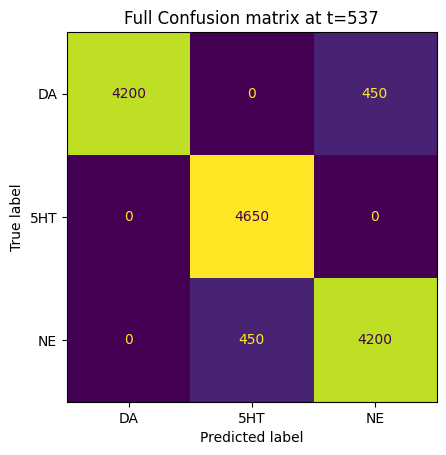

In [34]:

t_peak_full_raw = np.argmax(acc_over_t_full_raw_volta[2])
print(f"t_peak: {t_peak_full_raw}, acc: {acc_over_t_full_raw_volta[2][t_peak_full_raw]}")
X_tpeak_tr = train_full[0][:,t_peak_full_raw,:]
X_tpeak_test = test_full[0][:,t_peak_full_raw,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred_full= clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred_full, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Full Confusion matrix at t={t_peak_full_raw}")
plt.show()

In [35]:
fold_3d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_full_3d.npy")
train_full_3d, test_full_3d, y_mean_full_3d, y_std_full_3d, _, test_probe_full =  utils.load_activation_data(weights_paths,test_probe=best_probe,collapsed=False,ret_np=True)

Found 28 paths
Getting pairs not collapsed.
First activation shape(5250, 1000, 10)
First label shape(5250, 4)
Expert activation set shape: (127050, 1000, 10)
Labels shape: (127050, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 13950 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 13950 samples
Total valid samples: 97650
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'

Text(0, 0.5, 'Accuracy')

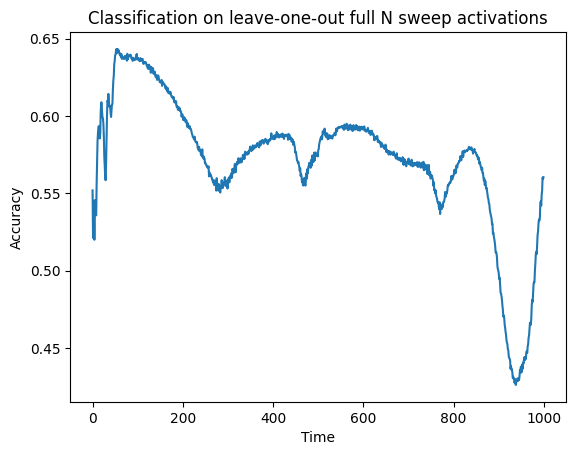

In [36]:
fold_3d_mean = fold_3d.mean(axis=0)

t_peak_3d_kfold = np.argmax(fold_3d_mean)

plt.plot(range(T), fold_3d_mean)
plt.title("Classification on leave-one-out full N sweep activations")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Found 28 paths
Getting pairs not collapsed.
First activation shape(5250, 1000, 10)
First label shape(5250, 4)
Expert activation set shape: (127050, 1000, 10)
Labels shape: (127050, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 13950 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 13950 samples
Total valid samples: 97650
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'

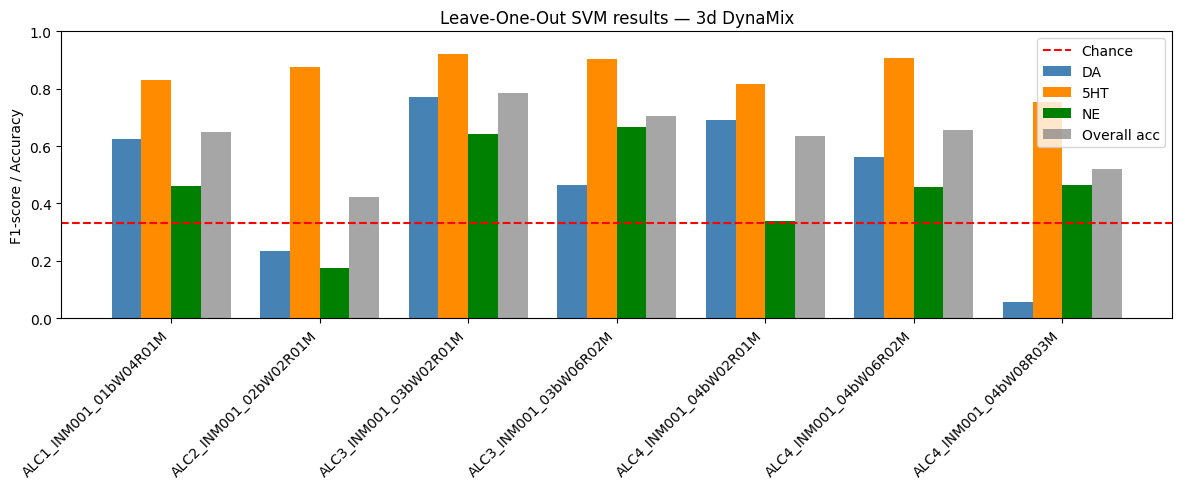

In [37]:
svm_results_3d_kfold = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_3d_kfold, collapsed=False)
plot_loo_results(svm_results_3d_kfold)

t_peak: 64, acc: 0.7823655913978494
              precision    recall  f1-score   support

          DA       0.69      0.87      0.77      4650
         5HT       0.90      0.92      0.91      4650
          NE       0.76      0.54      0.63      4650

    accuracy                           0.78     13950
   macro avg       0.79      0.78      0.77     13950
weighted avg       0.79      0.78      0.77     13950



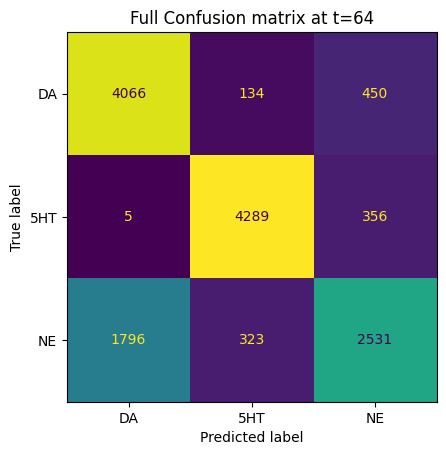

In [39]:

t_peak_full_3d_kfold = np.argmax(fold_3d[2])
print(f"t_peak: {t_peak_full_3d_kfold}, acc: {fold_3d[2][t_peak_full_3d_kfold]}")
X_tpeak_tr = train_full_3d[0][:,t_peak_full_3d_kfold,:]
X_tpeak_test = test_full_3d[0][:,t_peak_full_3d_kfold,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full_3d[1])

y_pred_full_3d= clf.predict(X_te_s)

print(classification_report(test_full_3d[1], y_pred_full_3d, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full_3d)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Full Confusion matrix at t={t_peak_full_3d_kfold}")
plt.show()

# Dynamix 3d classification over time results

In [3]:
acc_over_t_collapsed_over_electrode = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/acc_over_t_collapsed_over_electrode_3d.npy")
acc_over_t_full = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/acc_over_t_full_3d.npy")

Text(0, 0.5, 'Accuracy')

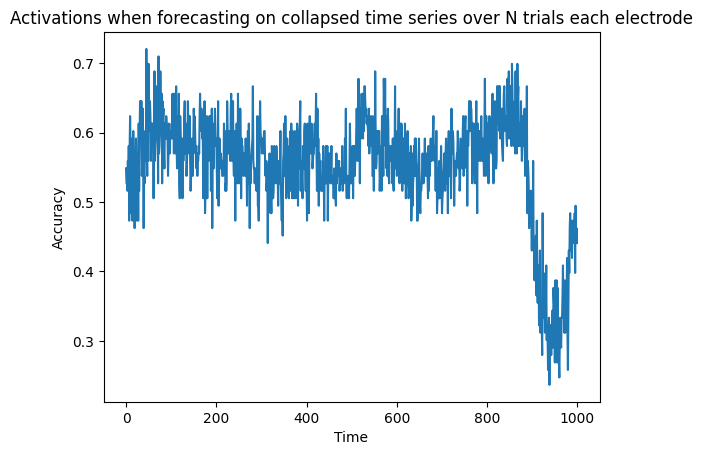

In [ ]:

plt.plot(range(T), acc_over_t_collapsed_over_electrode)
plt.title("Activations when forecasting on collapsed time series over N trials each electrode")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

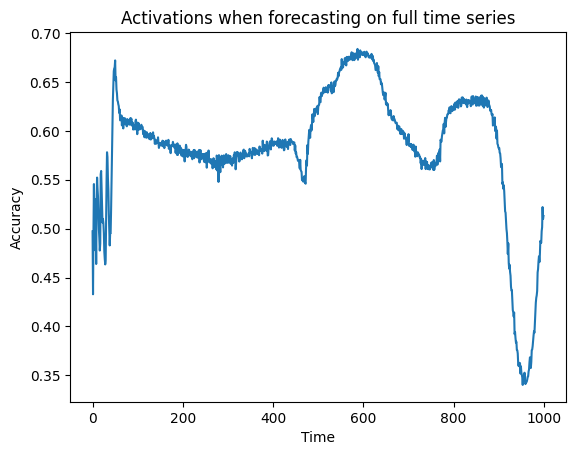

In [10]:
plt.plot(range(T), acc_over_t_full)
plt.title("Activations when forecasting on full time series")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [41]:
weights_paths = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
train_collapsed_per_electrode, test_collapsed_per_electrode, y_mean_collapsed_per_electrode, y_std_collapsed_per_electrode, mono_dom_list, test_probe_collapsed = utils.load_activation_data(weights_paths,test_probe="ALCIS_155_macroREF__ALC1_INM001_01bW04R01M",ret_np=True)
train_full, test_full, y_mean_full, y_std_full, _, test_probe_full =  utils.load_activation_data(weights_paths,test_probe="ALCIS_155_macroREF__ALC1_INM001_01bW04R01M",collapsed=False,ret_np=True)

Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 10)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 10)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

t_peak: 587, acc: 0.6837992831541219
              precision    recall  f1-score   support

          DA       0.58      0.83      0.69      4650
         5HT       0.79      0.82      0.81      4650
          NE       0.73      0.40      0.51      4650

    accuracy                           0.68     13950
   macro avg       0.70      0.68      0.67     13950
weighted avg       0.70      0.68      0.67     13950



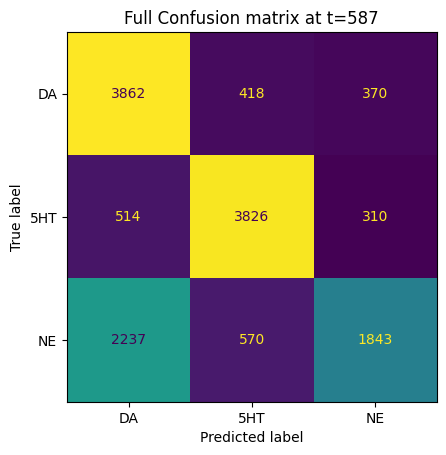

In [49]:

t_peak_full = np.argmax(acc_over_t_full)
print(f"t_peak: {t_peak_full}, acc: {acc_over_t_full[t_peak_full]}")
X_tpeak_tr = train_full[0][:,t_peak_full,:]
X_tpeak_test = test_full[0][:,t_peak_full,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred_full= clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred_full, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Full Confusion matrix at t={t_peak_full}")
plt.show()

t_peak: 45, acc: 0.7204301075268817
              precision    recall  f1-score   support

          DA       0.64      0.87      0.74        31
         5HT       0.81      0.81      0.81        31
          NE       0.70      0.45      0.55        31

    accuracy                           0.71        93
   macro avg       0.72      0.71      0.70        93
weighted avg       0.72      0.71      0.70        93



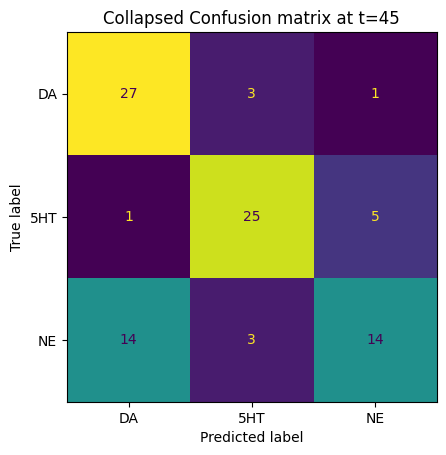

In [ ]:

t_peak_collapsed = np.argmax(acc_over_t_collapsed_over_electrode)
print(f"t_peak: {t_peak_collapsed}, acc: {acc_over_t_collapsed_over_electrode[t_peak_collapsed]}")
X_tpeak_tr = train_collapsed_per_electrode[0][:,t_peak_collapsed,:]
X_tpeak_test = test_collapsed_per_electrode[0][:,t_peak_collapsed,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_collapsed_per_electrode[1])

y_pred_collapsed = clf.predict(X_te_s)

print(classification_report(test_collapsed_per_electrode[1], y_pred_collapsed, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_collapsed_per_electrode[1], y_pred_collapsed)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Collapsed Confusion matrix at t={t_peak_collapsed}")
plt.show()

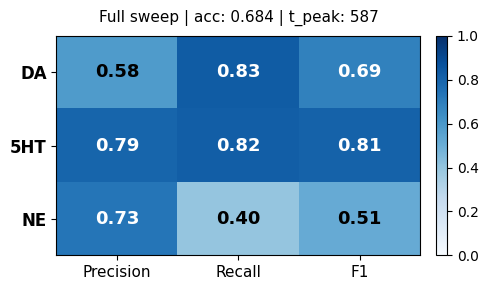

In [51]:
plot_classification_report(test_full[1], y_pred_full, t_peak_full, acc_over_t_full[t_peak_full], title="Full sweep")


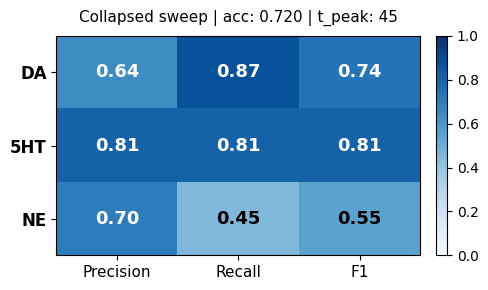

In [52]:
plot_classification_report(test_collapsed_per_electrode[1], y_pred_collapsed, t_peak_collapsed, acc_over_t_collapsed_over_electrode[t_peak_collapsed], title="Collapsed sweep")

# Top-K time points for classification

In [43]:
k=8
top_k_t_full = np.argpartition(acc_over_t_full, kth=-k)[-k:]
top_k_t_collapsed = np.argpartition(acc_over_t_collapsed_over_electrode, kth=-k)[-k:]


In [39]:
X_t_kth_peaks_tr = train_full[0][:,top_k_t_full,:]
X_t_kth_peaks_test = test_full[0][:,top_k_t_full,:]

X_t_kth_peaks_tr.reshape(-1, k*10).shape

(83700, 80)

              precision    recall  f1-score   support

          DA       0.58      0.90      0.70      4650
         5HT       0.80      0.82      0.81      4650
          NE       0.82      0.35      0.49      4650

    accuracy                           0.69     13950
   macro avg       0.73      0.69      0.67     13950
weighted avg       0.73      0.69      0.67     13950



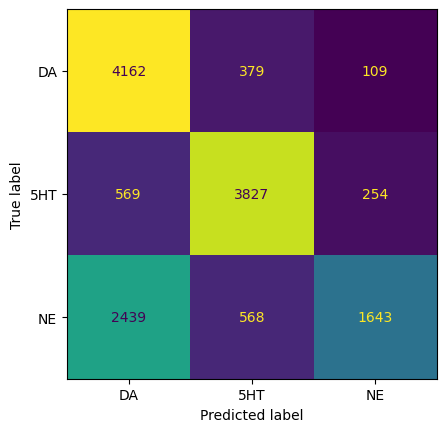

In [49]:

X_t_kth_peaks_tr = train_full[0][:,top_k_t_full,:]
X_t_kth_peaks_test = test_full[0][:,top_k_t_full,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_t_kth_peaks_tr.reshape(-1, k*10))
X_te_s = scaler.transform(X_t_kth_peaks_test.reshape(-1, k*10))

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred_full_topk= clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred_full_topk, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full_topk)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.show()

In [50]:
X_t_kth_peaks_tr = train_collapsed_per_electrode[0][:,top_k_t_collapsed,:]
X_t_kth_peaks_test = test_collapsed_per_electrode[0][:,top_k_t_collapsed,:]

X_t_kth_peaks_tr.shape

(558, 8, 10)

In [48]:
top_k_t_collapsed

array([863, 552,  48, 867, 855,  50,  72,  45])

              precision    recall  f1-score   support

          DA       0.64      0.74      0.69        31
         5HT       0.77      0.77      0.77        31
          NE       0.73      0.61      0.67        31

    accuracy                           0.71        93
   macro avg       0.71      0.71      0.71        93
weighted avg       0.71      0.71      0.71        93



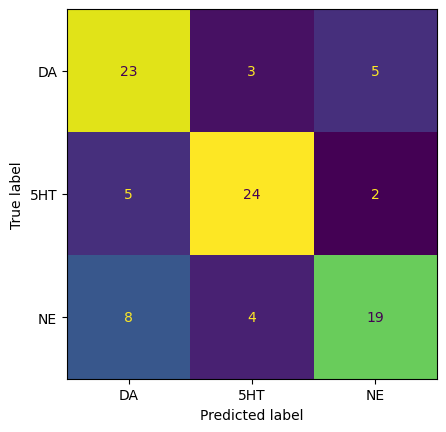

In [51]:

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_t_kth_peaks_tr.reshape(-1, k*10))
X_te_s = scaler.transform(X_t_kth_peaks_test.reshape(-1, k*10))

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_collapsed_per_electrode[1])

y_pred_collapsed_topk= clf.predict(X_te_s)

print(classification_report(test_collapsed_per_electrode[1], y_pred_collapsed_topk, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_collapsed_per_electrode[1], y_pred_collapsed_topk)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.show()

# Leave-One-Out on probes, 6D vs 3D

In [52]:
fold_3d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_collapsed_over_electrode_3d.npy")
fold_6d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_collapsed_over_electrode_6d.npy")

In [53]:
fold_3d = fold_3d.mean(axis=0)
fold_6d = fold_6d.mean(axis=0)

Text(0, 0.5, 'Accuracy')

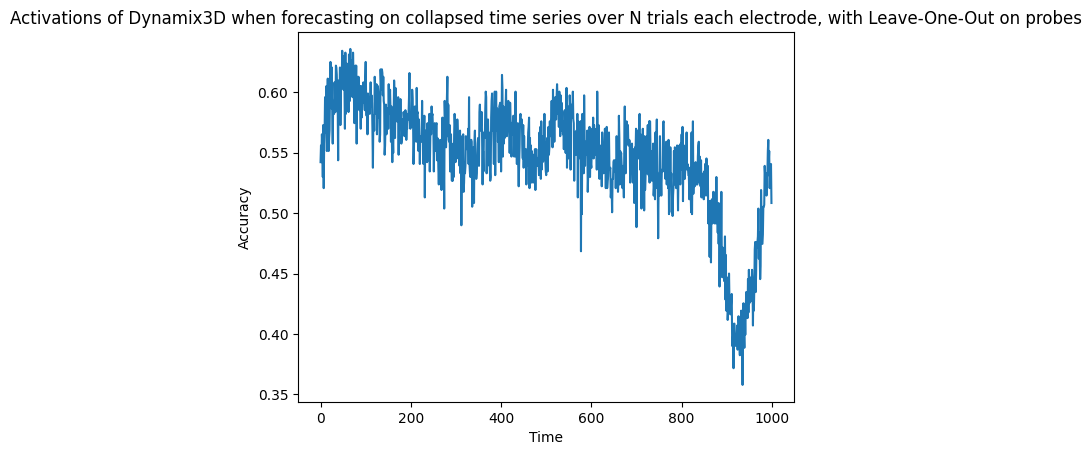

In [54]:
import matplotlib.pyplot as plt
plt.plot(range(T), fold_3d)
plt.title("Activations of Dynamix3D when forecasting on collapsed time series over N trials each electrode, with Leave-One-Out on probes")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

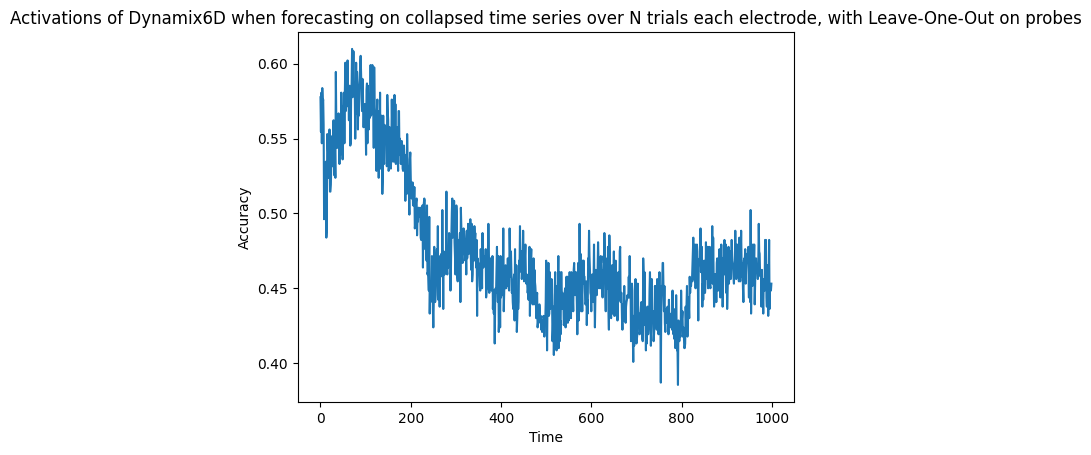

In [55]:
plt.plot(range(T), fold_6d)
plt.title("Activations of Dynamix6D when forecasting on collapsed time series over N trials each electrode, with Leave-One-Out on probes")
plt.xlabel("Time")
plt.ylabel("Accuracy")

# On maximal descriptive time point

In [56]:
t_peak_3d = np.argmax(fold_3d)
print(f"for 3D: t_peak {t_peak_3d}, acc {fold_3d[t_peak_3d]}")
t_peak_6d = np.argmax(fold_6d)
print(f"for 6D: t_peak {t_peak_6d}, acc {fold_3d[t_peak_6d]}")

for 3D: t_peak 66, acc 0.6359447004608294
for 6D: t_peak 70, acc 0.619047619047619


In [67]:
svm_results_3d = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_3d)


Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 10)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 10)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

In [68]:
svm_results_6d = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_6d,model_dim=None)


Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 80)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 80)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

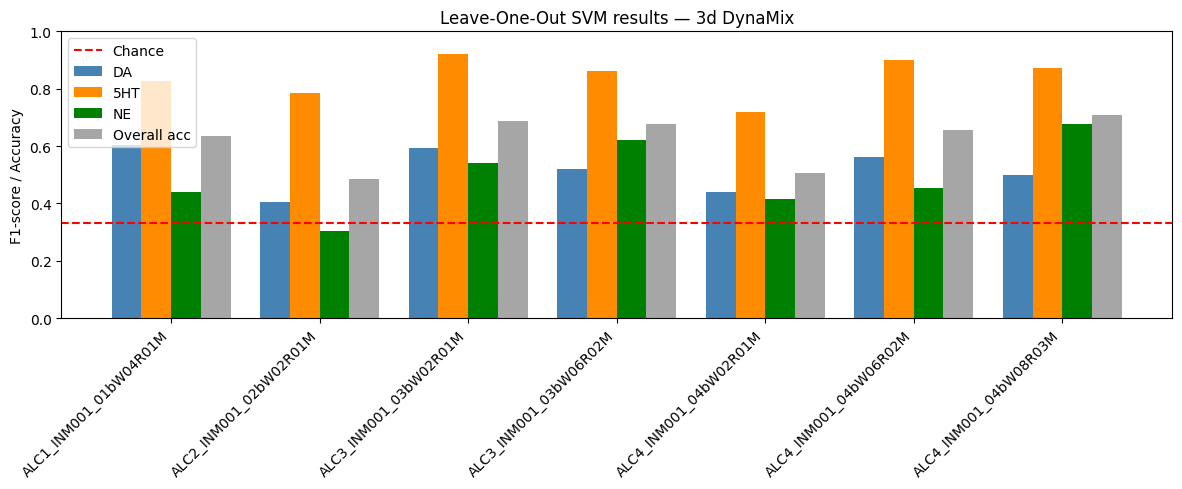

In [69]:
plot_loo_results(svm_results_3d)

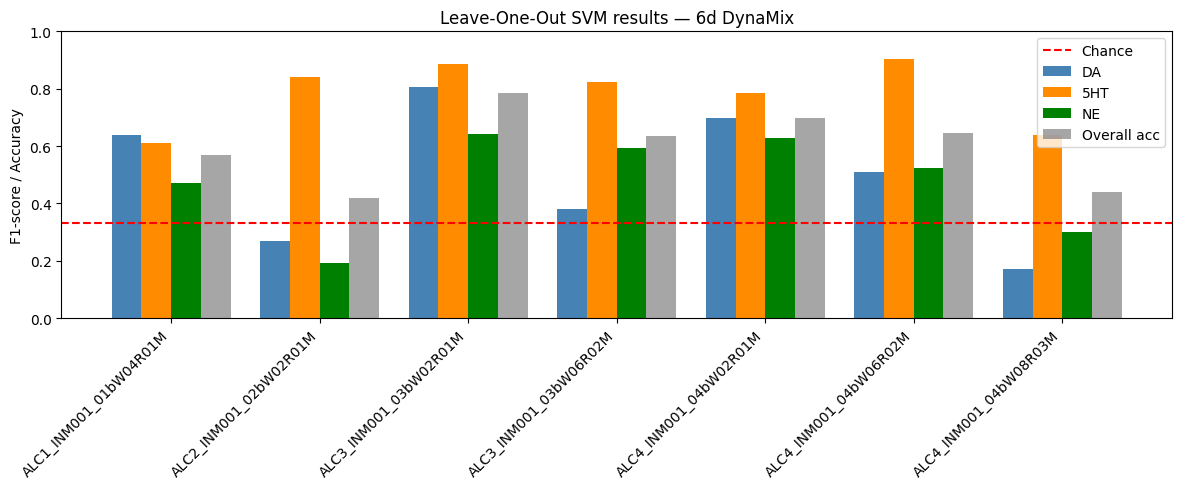

In [70]:
plot_loo_results(svm_results_6d, model_dim='6d')

In [71]:
def plot_model_comparison(results_3d, results_6d):
    metrics = ['DA', '5HT', 'NE', 'accuracy']
    
    def get_scores(results, metric):
        if metric == 'accuracy':
            return [v['acc'] for v in results.values()]
        return [v['report'][metric]['f1-score'] for v in results.values()]
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    
    for ax, metric in zip(axes, metrics):
        scores_3d = get_scores(results_3d, metric)
        scores_6d = get_scores(results_6d, metric)
        
        ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
        ax.axhline(1/3, color='red', linestyle='--', alpha=0.5)
        ax.set_title(metric)
        ax.set_ylim(0, 1)
    
    axes[0].set_ylabel('Score')
    plt.suptitle('3d vs 6d DynaMix — Leave-one-out SVM cross-validation')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

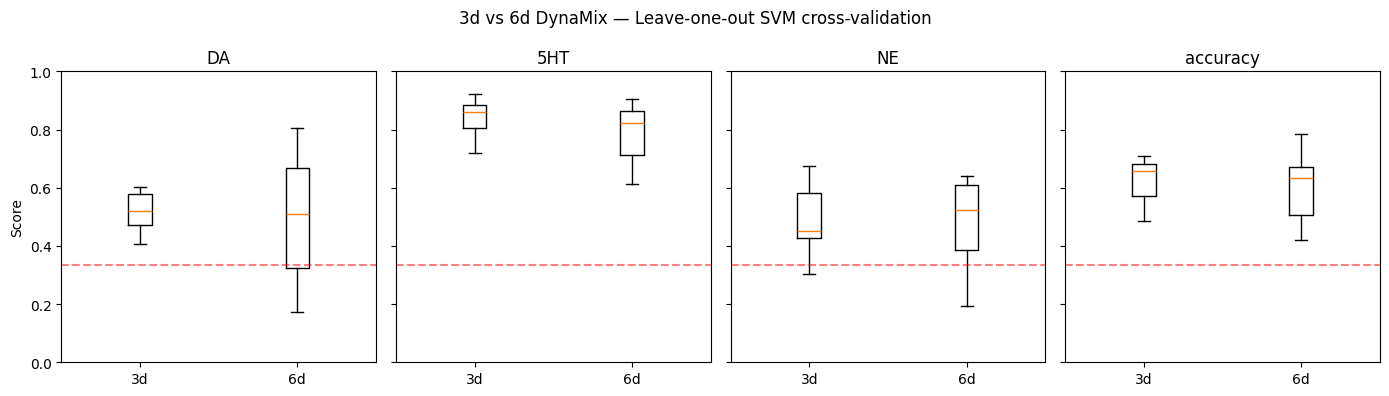

In [72]:
plot_model_comparison(svm_results_3d, svm_results_6d)

# On Top-K time points

In [63]:
k=8
t_k_peak_3d = np.argpartition(fold_3d,-k)[-k:]
t_k_peak_6d = np.argpartition(fold_6d,-k)[-k:]

In [73]:
topk_svm_results_3d = loo_svm_tpeak(probe_list=probes,t_peak=t_k_peak_3d, k=k)
topk_svm_results_6d = loo_svm_tpeak(probe_list=probes,t_peak=t_k_peak_6d, k=k, model_dim=None)



Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 10)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 10)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

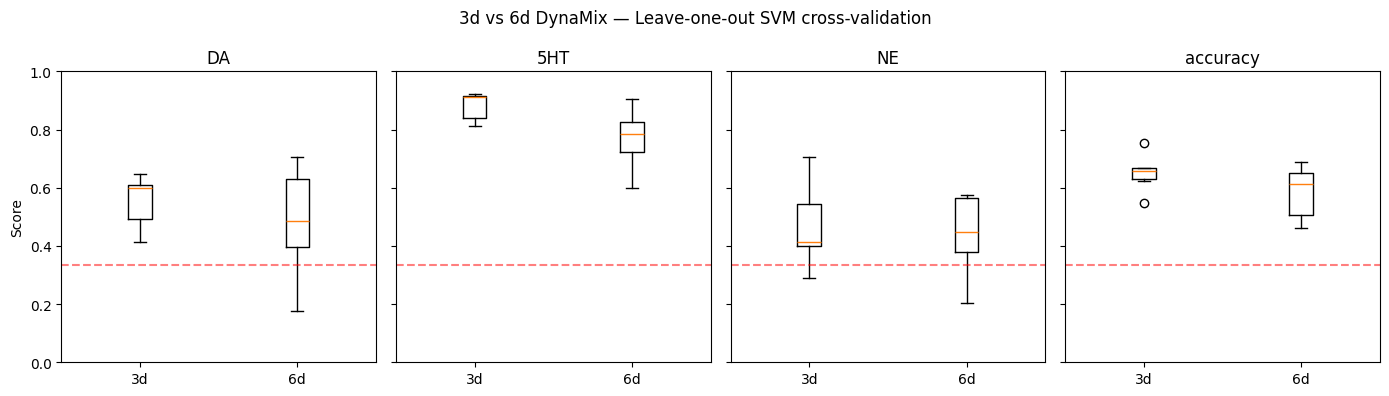

In [75]:
plot_model_comparison(topk_svm_results_3d, topk_svm_results_6d)

# Old results

Text(0, 0.5, 'Accuracy')

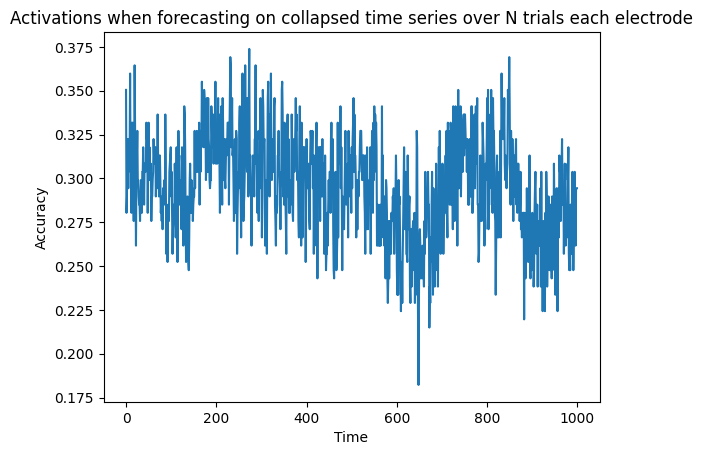

In [ ]:


plt.plot(range(T), acc_over_t_collapsed_over_electrode)
plt.title("Activations when forecasting on collapsed time series over N trials each electrode")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

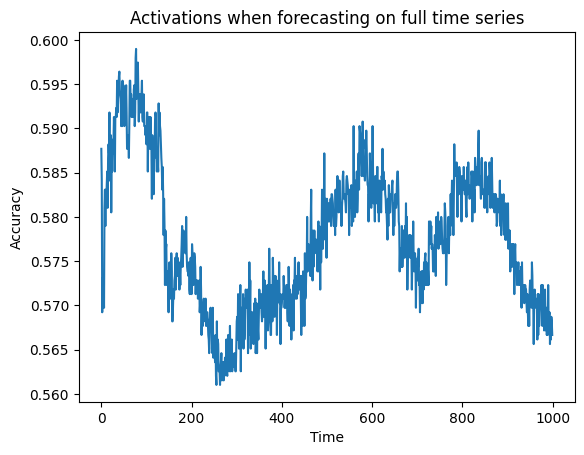

In [28]:
plt.plot(range(T), acc_over_t_full)
plt.title("Activations when forecasting on full time series")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [ ]:
print(acc_full_mean)
print(acc_collapsed_mean)

0.5948717948717949
0.308411214953271
